House price prediction training.

This notebooke is completed on colab , some of libraries may not included on requirement.txt file used in colab for model training

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muhamedumarjamil/house-price-prediction-dataset")

print("Path to dataset files:", path)

100%|██████████| 292k/292k [00:00<00:00, 40.9MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muhamedumarjamil/house-price-prediction-dataset/versions/1


In [ ]:
import os

# List contents of the directory to find the CSV file
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Assuming there's only one CSV file in the directory
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    print(df.head())
else:
    print("No CSV files found in the directory:", path)


   square_feet  num_rooms  age  distance_to_city(km)          price
0  2248.357077          3   92             22.997972  200374.090410
1  1930.867849          2   22             13.984254  268784.847337
2  2323.844269          6   33             21.500945  315020.857676
3  2761.514928          3   63             10.343638  355111.468459
4  1882.923313          7   54             25.485200  234197.123903


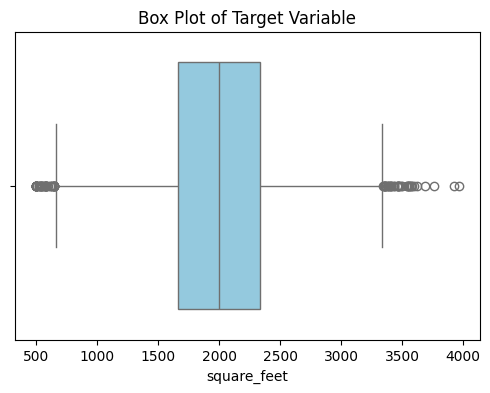

In [ ]:
# 1. Single Box Plot (To find outliers in a target variable)
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["square_feet"], color="skyblue")
plt.title("Box Plot of Target Variable")
plt.show()

In [ ]:
df.info

<bound method DataFrame.info of       square_feet  num_rooms  age  distance_to_city(km)          price
0     2248.357077          3   92             22.997972  200374.090410
1     1930.867849          2   22             13.984254  268784.847337
2     2323.844269          6   33             21.500945  315020.857676
3     2761.514928          3   63             10.343638  355111.468459
4     1882.923313          7   54             25.485200  234197.123903
...           ...        ...  ...                   ...            ...
9995  2650.551032          7    9             18.126034  431344.267823
9996  1000.827516          2   53             24.479692    6650.271134
9997  1647.341638          5   80              2.189312  233698.384301
9998  2247.882787          6   73             27.931014  280766.827379
9999  2322.194227          7   73             10.595721  342895.309114

[10000 rows x 5 columns]>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB


In [ ]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,263011.571609
std,501.021194,1.71116,28.992336,8.325101,98336.945117
min,500.000000,2.00000,0.000000,1.000161,-95613.138249
25%,1663.704735,3.00000,24.000000,8.121636,196791.510684
50%,1998.702512,4.00000,49.000000,15.403146,262497.361236
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


handeled fillna and outliers

In [ ]:
df.price.fillna(df.price.mean(), inplace=True)
df.num_rooms.fillna(df.num_rooms.mean(), inplace=True)
df.age.fillna(df.age.mean(), inplace=True)

/tmp/ipykernel_809/1510739619.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.price.fillna(df.price.mean(), inplace=True)
/tmp/ipykernel_809/1510739619.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [ ]:
df.price

,price
0,200374.090410
1,268784.847337
2,315020.857676
3,355111.468459
4,234197.123903
...,...
9995,431344.267823
9996,6650.271134
9997,233698.384301
9998,280766.827379


In [ ]:
df.describe()

,square_feet,num_rooms,age,distance_to_city(km),price
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1999.147496,4.49510,49.516900,15.362148,264106.442714
std,501.021194,1.71116,28.992336,8.325101,96704.657203
min,500.000000,2.00000,0.000000,1.000161,1059.396373
25%,1663.704735,3.00000,24.000000,8.121636,197808.616605
50%,1998.702512,4.00000,49.000000,15.403146,263011.571609
75%,2335.540444,6.00000,75.000000,22.447530,330445.581908
max,3963.118853,7.00000,99.000000,29.993892,660168.255648


In [ ]:
mean_price = df['price'].mean()
df.loc[df['price'] < 0, 'price'] = mean_price

In [ ]:
from sklearn.model_selection import train_test_split

X = df[['square_feet', 'num_rooms', 'age', 'distance_to_city(km)']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


y_pred = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²  :", r2_score(y_test, y_pred))

MAE : 16542.99761721525
MSE : 610135472.489687
RMSE: 24700.92047859122
R²  : 0.9351115635273293


In [ ]:
lr.predict([[1900,2,10,15]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([241919.77160965])

In [ ]:
lr.score(df[['square_feet','num_rooms','age','distance_to_city(km)']],df.price)

0.9280905432143274

In [ ]:
lr.coef_

array([  144.66418731, 19326.54504863,  -979.04972289, -4851.07210979])

In [ ]:
lr.intercept_

np.float64(10961.304489693837)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import joblib

# Define the path to save the model in Google Drive
model_save_path = '/content/drive/My Drive/linear_regression_model.joblib'

# Save the model
joblib.dump(lr, model_save_path)
print(f"Model saved successfully to: {model_save_path}")

Model saved successfully to: /content/drive/My Drive/linear_regression_model.joblib
